In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


In [37]:
# using 'Science' style plots
plt.style.use(['science', 'high-vis'])

J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
alpha1, alpha2 = sp.symbols("alpha1 alpha2", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

In [27]:
def L_eff(N, num_dimers=1):
    # building matrices
    H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j} in [{k, k+1} for k in range(num_dimers)]) else 0)
    V = sp.Matrix(N, N, lambda i,j : epsilon if ( {i,j} in [{k, k+1} for k in range(num_dimers,N+1)] ) else 0 )

    # building lindblad jump operators
    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    
    # building lindbladians
    L0, rho = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
    L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)
    
    # setting all dephasing constants to the same constant gamma
    L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})
    
    # constructing projector (and its complement)
    nullspace = [n/n.norm() for n in L0.nullspace()]
    P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
    Q = sp.eye(sp.shape(P)[0]) - P

    # building Leff and Leff_red
    Leff = ((Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P).applyfunc(lambda i: i.simplify(deep=True))
    Leff_red = sp.Matrix(len(nullspace), len(nullspace), lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))

    return rho, L0+L1, Leff, Leff_red

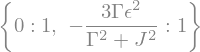

In [33]:
_, _, _, Leff_red = L_eff(3, num_dimers=1)
Leff_red.eigenvals()

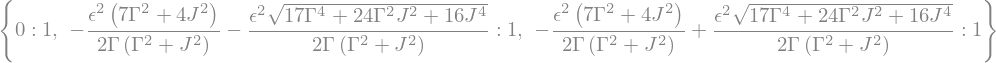

In [34]:
_, _, _, Leff_red = L_eff(4, num_dimers=1)
Leff_red.eigenvals()

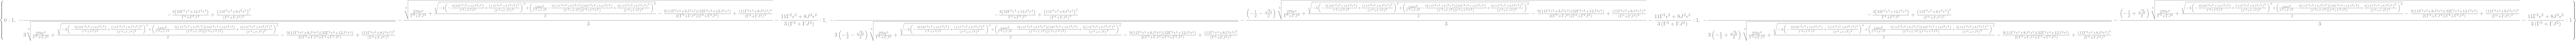

In [35]:
_, _, _, Leff_red = L_eff(5, num_dimers=1)
Leff_red.eigenvals()

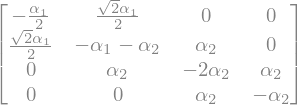

In [77]:
N=5

_, _, _, Leff_red = L_eff(N, num_dimers=1)

a = Leff_red.subs({ gamma*epsilon**2 / (gamma**2 + J**2) : alpha1/2 , 2*epsilon**2 / gamma : alpha2})
a

In [82]:
mathematica_code(a).replace("Gamma","Γ").replace("alpha1", "Subscript[α,1]").replace("alpha2", "Subscript[α,2]")

'{{-1/2*Subscript[α,1], (1/2)*2^(1/2)*Subscript[α,1], 0, 0}, {(1/2)*2^(1/2)*Subscript[α,1], -Subscript[α,1] - Subscript[α,2], Subscript[α,2], 0}, {0, Subscript[α,2], -2*Subscript[α,2], Subscript[α,2]}, {0, 0, Subscript[α,2], -Subscript[α,2]}}'

In [76]:
scipy.linalg.eigvals(np.array(Leff_red.subs({gamma:1e-6, J:0.1, epsilon:1e-4})).astype(complex))

array([-4.00000000e-02+0.j, -1.99999666e-12+0.j, -2.42534782e-18+0.j])